# Análisis de caso: métricas de desempeño de un modelo de regresión

Caso AutoPredict S.A.: predicción de precio de vehículos usados según antigüedad, kilometraje y número de puertas.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 1. Crear el dataset

Datos ficticios entregados por el cliente para 5 vehículos.

In [8]:
data = {
    'Antiguedad': [5, 3, 7, 4, 2],
    'Kilometraje': [50000, 30000, 70000, 9000, 25000],
    'Puertas': [4, 2, 4, 2, 2],
    'Precio': [12000, 15000, 9000, 16000, 14000]
}

df = pd.DataFrame(data)
df

,Antiguedad,Kilometraje,Puertas,Precio
0,5,50000,4,12000
1,3,30000,2,15000
2,7,70000,4,9000
3,4,9000,2,16000
4,2,25000,2,14000


## 2. Definir variables y dividir en entrenamiento y prueba (60/40)

In [9]:
X = df[['Antiguedad', 'Kilometraje', 'Puertas']]
y = df['Precio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

X_train, X_test, y_train, y_test

(   Antiguedad  Kilometraje  Puertas
 2           7        70000        4
 0           5        50000        4
 3           4         9000        2,
    Antiguedad  Kilometraje  Puertas
 1           3        30000        2
 4           2        25000        2,
 2     9000
 0    12000
 3    16000
 Name: Precio, dtype: int64,
 1    15000
 4    14000
 Name: Precio, dtype: int64)

## 3. Crear y entrenar el modelo de regresión lineal

In [10]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('Intercepto:', modelo.intercept_)
print('Coeficientes:', modelo.coef_)

Intercepto: 18236.223383582004
Coeficientes: [-4.89713449e+02 -1.01028655e-01  3.15944154e+02]


## 4. Realizar predicciones y calcular métricas (MAE, MSE, RMSE, R²)

In [11]:
y_pred = modelo.predict(X_test)

print('Valores reales de test :', list(y_test))
print('Valores predichos      :', list(y_pred))

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Métricas de desempeño:')
print(f'MAE : {mae:.2f}')
print(f'MSE : {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²  : {r2:.4f}')

Valores reales de test : [15000, 14000]
Valores predichos      : [np.float64(14368.111691791002), np.float64(15362.968416273423)]
Métricas de desempeño:
MAE : 997.43
MSE : 1128482.87
RMSE: 1062.30
R²  : -3.5139


## 5. Gráfico comparativo: precios reales vs. predichos

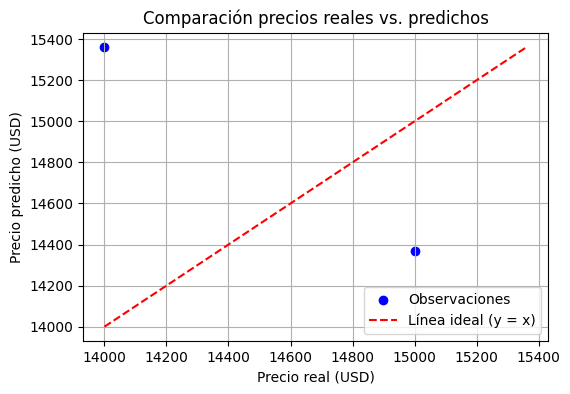

In [12]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='blue', label='Observaciones')

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Línea ideal (y = x)')

plt.xlabel('Precio real (USD)')
plt.ylabel('Precio predicho (USD)')
plt.title('Comparación precios reales vs. predichos')
plt.legend()
plt.grid(True)
plt.show()

## 6. Informe breve (para el entregable)

### 6.1. Métricas obtenidas e interpretación

Con `test_size = 0.4` el conjunto de prueba queda con 2 observaciones, por lo que es válido calcular R². Una vez ejecutado el notebook, interpreta las métricas así:

- **MAE**: error absoluto promedio en dólares entre los precios reales y los predichos del conjunto de prueba. Valores pequeños respecto al rango de precios (por ejemplo, menos del 10–15 % del precio promedio) indican un modelo razonablemente preciso.
- **MSE**: promedio de los errores al cuadrado. Penaliza fuertemente las predicciones muy alejadas y es útil para comparar varios modelos, aunque queda en unidades de USD².
- **RMSE**: raíz del MSE; vuelve a la unidad original (USD) y puede leerse como el “error típico” del modelo. Se recomienda compararlo con el precio medio del dataset.
- **R²**: proporción de la variabilidad de los precios en el conjunto de prueba explicada por el modelo. Valores cercanos a 1 implican buen ajuste; valores cercanos a 0 indican que el modelo apenas mejora sobre predecir siempre el promedio; valores negativos señalan que el modelo es peor que esa referencia. Con solo 2 datos en test, R² sigue siendo inestable, pero ya es computable.

### 6.2. Decisiones para mejorar el modelo

- **Aumentar el tamaño del dataset**: con 5 registros (3 para entrenamiento y 2 para prueba) las métricas son muy sensibles. Es recomendable entrenar con muchos más ejemplos reales de ventas.
- **Agregar variables relevantes**: incluir marca, modelo, tipo de combustible, potencia, equipamiento o estado del vehículo puede mejorar la capacidad explicativa del modelo.
- **Revisar el preprocesamiento**: detectar y tratar valores atípicos, corregir posibles errores de carga y considerar escalamiento de variables si se usan modelos sensibles a la escala.
- **Probar otros algoritmos**: además de la regresión lineal, evaluar regresión polinómica, árboles de decisión o Random Forest y comparar sus métricas mediante un mismo esquema de validación.
- **Validación cruzada**: usar K-Fold cross‑validation para obtener métricas promedio menos dependientes de una única partición 60/40.

### 6.3. Gráfico comparando precios reales y predichos

- Si los puntos se alinean cerca de la línea roja (y = x), el modelo reproduce razonablemente bien los precios de prueba.
- Puntos alejados de la línea representan errores grandes; conviene analizarlos para detectar posibles outliers o patrones que el modelo lineal no está capturando correctamente.